In [2]:
# ── IMPORTS ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── DATA LOADING ─────────────────────────────────────
train = pd.read_csv("../house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("../house-prices-advanced-regression-techniques/test.csv")

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [4]:
train.head()
# shows first 5 rows, you see what the data actually looks like

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.info()
# shows which columns are numeric vs text (object)
# also shows non-null counts per column

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [6]:
train.describe()
# shows min, max, mean for every numeric column
# look for weird values like GrLivArea=0 or YearBuilt=1800

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


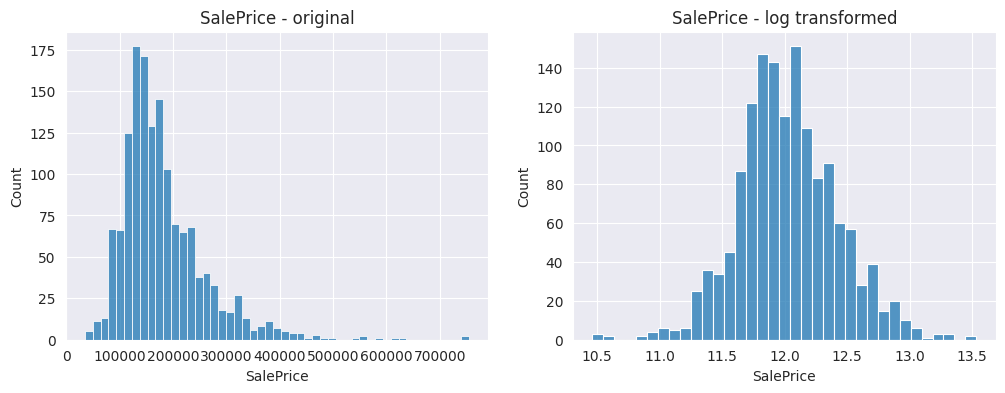

Skewness original: 1.8828757597682129
Skewness log: 0.12134661989685333


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train["SalePrice"], ax=axes[0])
axes[0].set_title("SalePrice - original")

sns.histplot(np.log1p(train["SalePrice"]), ax=axes[1])
axes[1].set_title("SalePrice - log transformed")

plt.show()

print("Skewness original:", train["SalePrice"].skew())
print("Skewness log:", np.log1p(train["SalePrice"]).skew())
# skewness close to 0 = good, log transformation usually fixes this

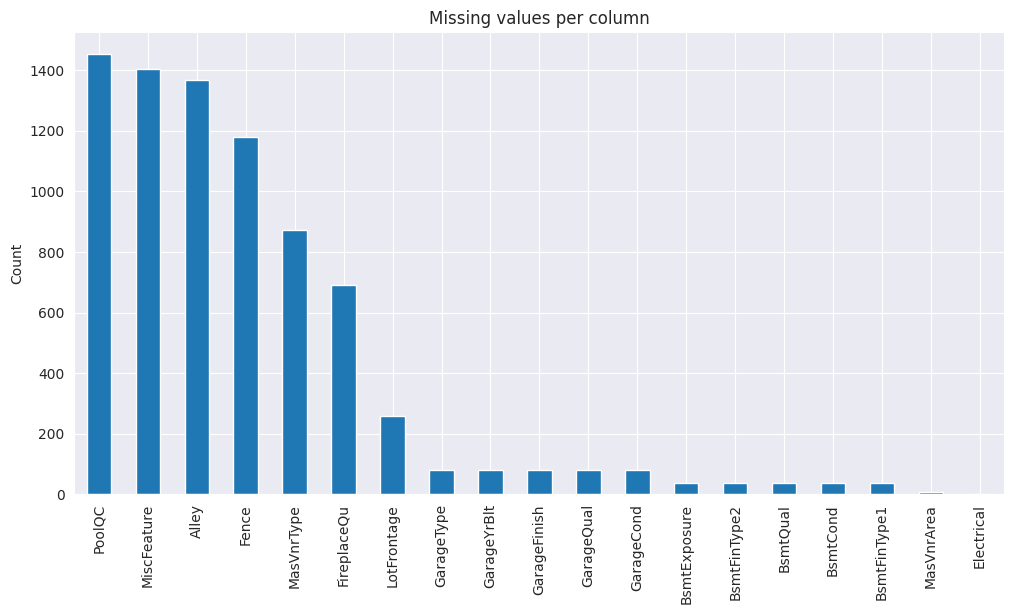

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [8]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
missing.plot(kind="bar")
plt.title("Missing values per column")
plt.ylabel("Count")
plt.show()

print(missing)

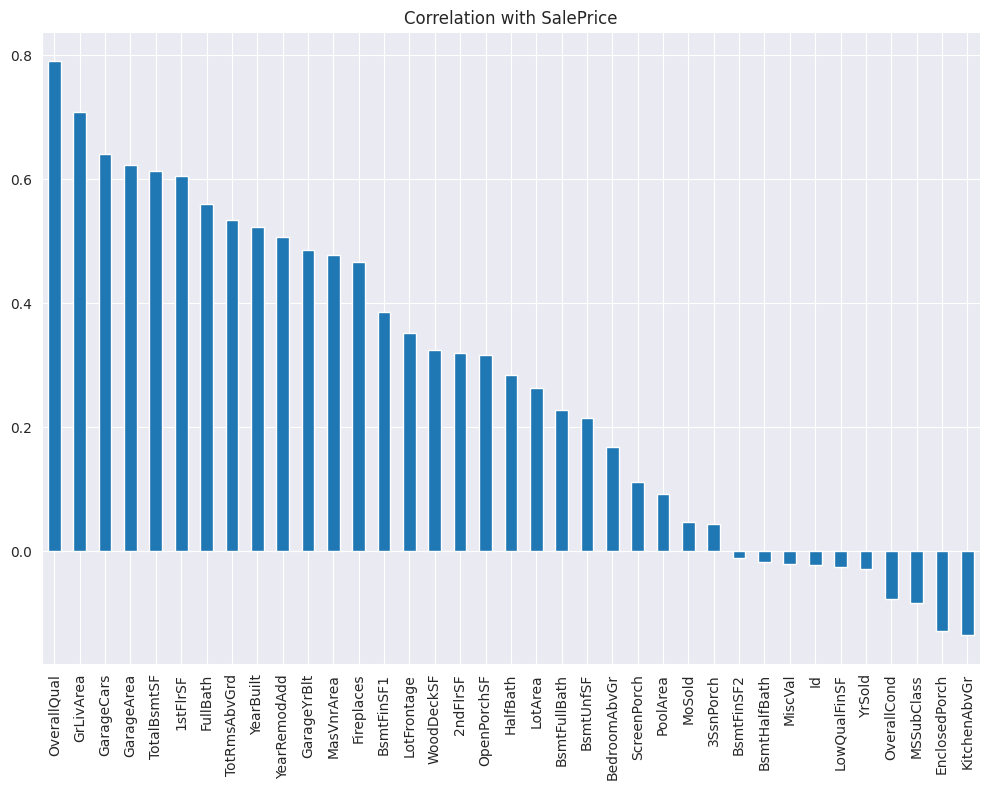

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [9]:
corr = train.select_dtypes(include=np.number).corr()["SalePrice"]
corr = corr.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr.drop("SalePrice").plot(kind="bar")
plt.title("Correlation with SalePrice")
plt.tight_layout()
plt.show()

print(corr)

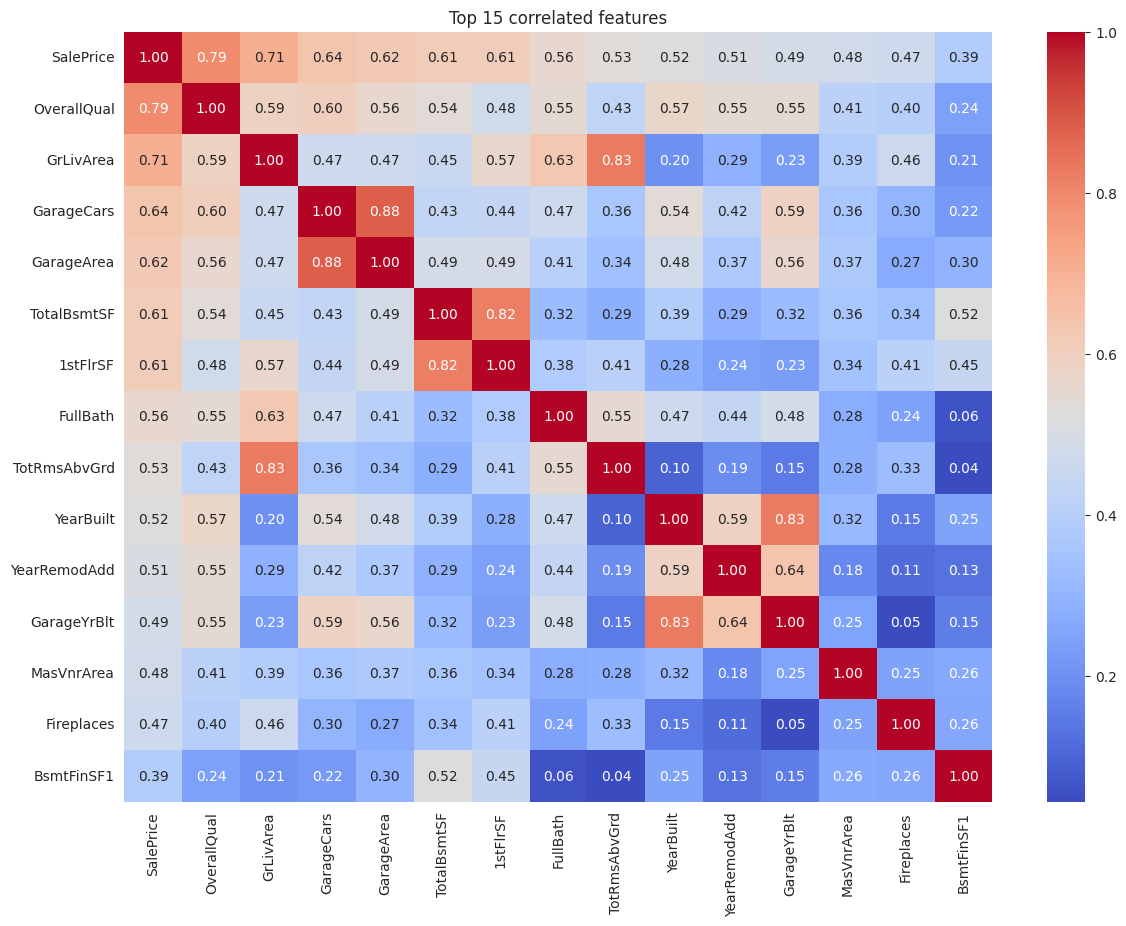

In [10]:
plt.figure(figsize=(14, 10))
top_corr_cols = corr.abs().sort_values(ascending=False).head(15).index
sns.heatmap(train[top_corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top 15 correlated features")
plt.show()

In [14]:
cat_cols = train.select_dtypes(include="str").columns
print(f"Categorical columns: {len(cat_cols)}")
print(cat_cols.tolist())

for col in cat_cols:
    print(f"{col}: {train[col].nunique()} unique values — {train[col].unique()[:5]}")

Categorical columns: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
MSZoning: 5 unique values — <StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str
Street: 2 unique values — <StringArray>
['Pave', 'Grvl']
Length: 2, dtype: str
Alley: 2 unique values — <StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str
LotShape: 4 unique values — <StringArray>
['Reg', 'IR1', 'IR2', 'IR3']
Length: 4, dtype: str
LandContour: 4 unique values — <StringArr

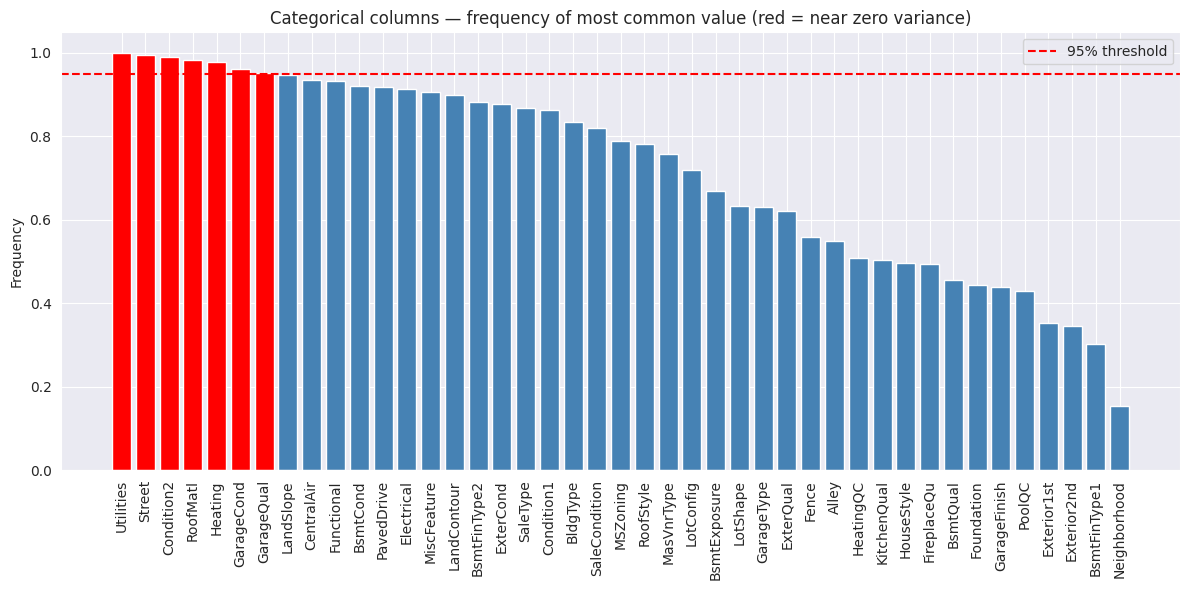

Near zero variance columns (>95%):
        column  top_frequency top_value
5    Utilities       0.999315    AllPub
1       Street       0.995890      Pave
10  Condition2       0.989726      Norm
14    RoofMatl       0.982192   CompShg
26     Heating       0.978082      GasA
36  GarageCond       0.961566        TA
35  GarageQual       0.950689        TA


In [15]:
# ── NEAR ZERO VARIANCE ────────────────────────────────────

cat_cols = train.select_dtypes(include="str").columns
num_cols = train.select_dtypes(include=np.number).columns

# For categorical — show % of most common value
cat_variance = []
for col in cat_cols:
    top_freq = train[col].value_counts(normalize=True).iloc[0]
    top_val = train[col].value_counts().index[0]
    cat_variance.append({"column": col, "top_frequency": top_freq, "top_value": top_val})

cat_variance_df = pd.DataFrame(cat_variance).sort_values("top_frequency", ascending=False)

plt.figure(figsize=(12, 6))
colors = ["red" if x > 0.95 else "steelblue" for x in cat_variance_df["top_frequency"]]
plt.bar(cat_variance_df["column"], cat_variance_df["top_frequency"], color=colors)
plt.axhline(y=0.95, color="red", linestyle="--", label="95% threshold")
plt.xticks(rotation=90)
plt.title("Categorical columns — frequency of most common value (red = near zero variance)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

print("Near zero variance columns (>95%):")
print(cat_variance_df[cat_variance_df["top_frequency"] > 0.95][["column", "top_frequency", "top_value"]])